In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer  # Importa PowerTransformer
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, hinge_loss
from sklearn.linear_model import LogisticRegression



# Caricare i dati dal CSV
file_path = 'Data/features_30_sec.csv'
data = pd.read_csv(file_path)

# Stampa i nomi delle colonne per verificare
#print("Colonne nel DataFrame:", data.columns)

# Separare le caratteristiche e le etichette
X = data.drop(columns=['filename', 'label'])  # Rimuovi filename e label
y = data['label']  # Etichette

# Suddividere il dataset in set di addestramento e test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizzare le caratteristiche
robust = RobustScaler()
standard = StandardScaler()
minmax = MinMaxScaler()
power = PowerTransformer()
scalers=[robust, standard, minmax, power]




senza nulla

In [16]:
# Definizione del modello di Logistic Regression
model = LogisticRegression(max_iter=1000, solver='newton-cg')
model.fit(X_train, y_train)

    # Valutazione del modello
y_pred = model.predict(X_test)

    # Calcolare metriche
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')  # Macro per bilanciare le classi
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')  # F2-score con beta=2

    # Stampare i risultati
print(f'Accuratezza: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')
print(f'F2-score: {f2:.4f}')
print('------------------------------------------------------------')

Accuratezza: 0.6250
Precision: 0.6366
Recall: 0.6399
F1-score: 0.6315
F2-score: 0.6349
------------------------------------------------------------


c:\Users\romeo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\optimize.py:318: ConvergenceWarning: newton-cg failed to converge at loss = 0.6316943424967308. Increase the number of iterations.
  warnings.warn(


con standardizzazione

In [8]:
for scaler in scalers:

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Definizione del modello di Logistic Regression
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    # Valutazione del modello
    y_pred = model.predict(X_test)

    # Calcolare metriche
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')  # Macro per bilanciare le classi
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')  # F2-score con beta=2

    # Stampare i risultati
    print(f'Scaler: {scaler.__class__.__name__}')
    print(f'Accuratezza: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-score: {f1:.4f}')
    print(f'F2-score: {f2:.4f}')
    print('------------------------------------------------------------')

Scaler: RobustScaler
Accuratezza: 0.7300
Precision: 0.7407
Recall: 0.7470
F1-score: 0.7327
F2-score: 0.7385
------------------------------------------------------------
Scaler: StandardScaler
Accuratezza: 0.7100
Precision: 0.7263
Recall: 0.7291
F1-score: 0.7229
F2-score: 0.7255
------------------------------------------------------------
Scaler: MinMaxScaler
Accuratezza: 0.6250
Precision: 0.6429
Recall: 0.6497
F1-score: 0.6384
F2-score: 0.6434
------------------------------------------------------------
Scaler: PowerTransformer
Accuratezza: 0.7250
Precision: 0.7356
Recall: 0.7358
F1-score: 0.7300
F2-score: 0.7320
------------------------------------------------------------


grid search

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

 #Definizione del pipeline con standardizzazione e Logistic Regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Standardizzazione delle features
    ('classifier', LogisticRegression(max_iter=1000))  # Classificatore Logistic Regression
])

# Definizione degli iperparametri da testare con GridSearch, con combinazioni compatibili
param_grid = [
    {'classifier__C': [0.01, 0.1, 1], 'classifier__penalty': ['l2'], 'classifier__solver': ['lbfgs']},
    {'classifier__C': [0.01, 0.1, 1], 'classifier__penalty': ['l1', 'l2'], 'classifier__solver': ['liblinear']},
    {'classifier__C': [0.01, 0.1, 1], 'classifier__penalty': ['l1', 'l2', 'elasticnet'], 
     'classifier__solver': ['saga'], 'classifier__l1_ratio': [0.5]}  # l1_ratio solo per elasticnet con saga
]

# Inizializzazione della GridSearchCV con validazione incrociata a 5 fold
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Esecuzione della ricerca
grid_search.fit(X_train, y_train)

# Migliori parametri trovati
print("Migliori iperparametri trovati:", grid_search.best_params_)
print("Migliore accuratezza ottenuta:", grid_search.best_score_)

# Valutazione del modello sul set di test
best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print("Accuratezza sul set di test:", test_accuracy)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Migliori iperparametri trovati: {'classifier__C': 1, 'classifier__l1_ratio': 0.5, 'classifier__penalty': 'elasticnet', 'classifier__solver': 'saga'}
Migliore accuratezza ottenuta: 0.7387499999999999
Accuratezza sul set di test: 0.72


con grid e standardizzazione

In [10]:
for scaler in scalers:

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Definizione del modello di Logistic Regression
    model = LogisticRegression(max_iter=1000, C=  1, l1_ratio=0.5, penalty= 'elasticnet', solver= 'saga')
    model.fit(X_train, y_train)

    # Valutazione del modello
    y_pred = model.predict(X_test)

    # Calcolare metriche
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')  # Macro per bilanciare le classi
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')  # F2-score con beta=2

    # Stampare i risultati
    print(f'Scaler: {scaler.__class__.__name__}')
    print(f'Accuratezza: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-score: {f1:.4f}')
    print(f'F2-score: {f2:.4f}')
    print('------------------------------------------------------------')

c:\Users\romeo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Scaler: RobustScaler
Accuratezza: 0.6900
Precision: 0.7067
Recall: 0.7060
F1-score: 0.6953
F2-score: 0.6991
------------------------------------------------------------
Scaler: StandardScaler
Accuratezza: 0.7350
Precision: 0.7466
Recall: 0.7454
F1-score: 0.7413
F2-score: 0.7425
------------------------------------------------------------
Scaler: MinMaxScaler
Accuratezza: 0.6700
Precision: 0.7014
Recall: 0.6891
F1-score: 0.6860
F2-score: 0.6854
------------------------------------------------------------
Scaler: PowerTransformer
Accuratezza: 0.7350
Precision: 0.7466
Recall: 0.7454
F1-score: 0.7413
F2-score: 0.7425
------------------------------------------------------------


FACCIO IL LASSO

Accuratezza per ogni fold: [0.68, 0.7, 0.79, 0.68, 0.79, 0.74, 0.73, 0.76, 0.75, 0.67]
Accuratezza media dopo K-Fold: 0.7290
Numero Feature selezionate: 52

Feature selezionate dal Lasso: ['length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'perceptr_mean', 'perceptr_var', 'tempo', 'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean', 'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean', 'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var', 'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean', 'mfcc19_mean', 'mfcc20_mean', 'mfcc20_var']
F

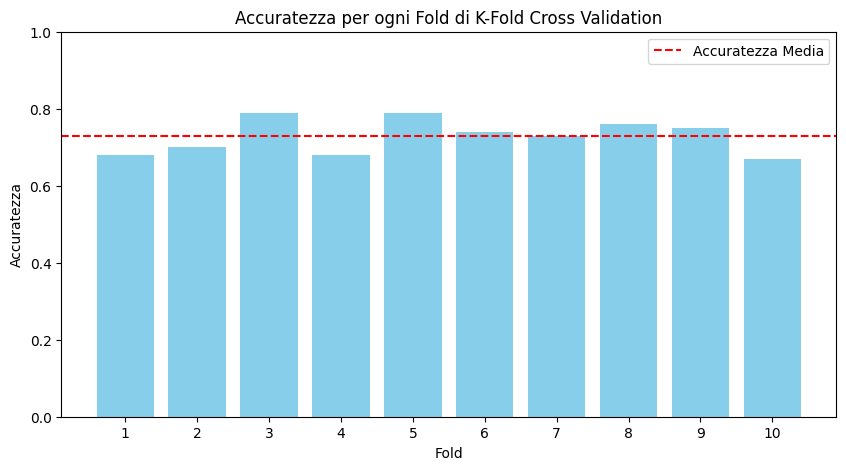

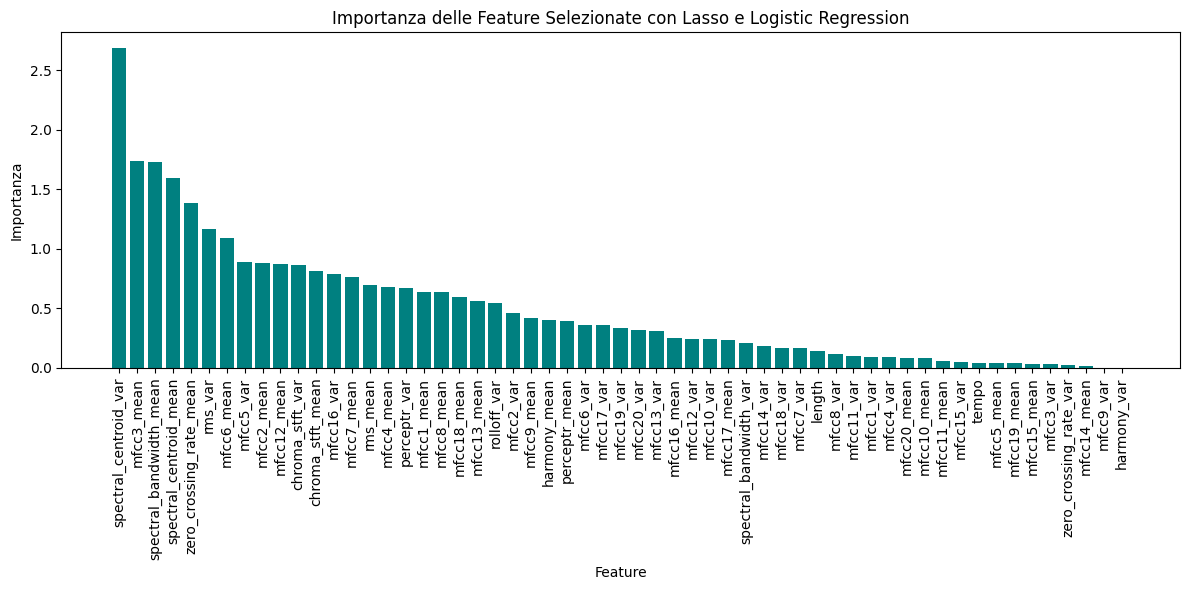

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Carica i dati dal CSV
file_path = 'Data/features_30_sec.csv'
data = pd.read_csv(file_path)

# Separare le caratteristiche e le etichette
X = data.drop(columns=['filename', 'label'])
y = data['label']

# Converti le etichette in valori numerici
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Standardizza le caratteristiche
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Inizializza la cross-validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Variabili per la valutazione
accuracies = []
importances_dict = {}  # Dizionario per tracciare le importanze delle feature selezionate

# Loop attraverso ogni fold
for train_index, test_index in kf.split(X_scaled, y_encoded):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]

    # Selezione delle feature con Lasso
    lasso = Lasso(alpha=0.01)
    lasso.fit(X_train, y_train)

    # Seleziona le feature non nulle
    selected_features = np.where(lasso.coef_ != 0)[0]
    X_train_selected = X_train[:, selected_features]
    X_test_selected = X_test[:, selected_features]

    # Addestra il modello Logistic Regression sulle feature selezionate
    model = LogisticRegression(max_iter=10000, C=  1, l1_ratio=0.5, penalty= 'elasticnet', solver= 'saga')
    model.fit(X_train_selected, y_train)

    # Calcolare l'importanza delle feature (usiamo i coefficienti della Logistic Regression)
    importances = np.abs(model.coef_[0])  # Prendiamo il valore assoluto dei coefficienti
    
    # Salvare le importanze con il nome della feature
    for i, feature_index in enumerate(selected_features):
        feature_name = X.columns[feature_index]
        if feature_name in importances_dict:
            importances_dict[feature_name].append(importances[i])
        else:
            importances_dict[feature_name] = [importances[i]]

    # Valuta il modello
    y_pred = model.predict(X_test_selected)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

# Risultati finali
print(f"Accuratezza per ogni fold: {accuracies}")
print(f"Accuratezza media dopo K-Fold: {np.mean(accuracies):.4f}")
print(f"Numero Feature selezionate: {len(selected_features)}")
selected_feature_names = X.columns[selected_features].tolist()
print("\nFeature selezionate dal Lasso:", selected_feature_names)
print(f"Feature selezionate: {(selected_features)}")

# Calcolare la media delle importanze delle feature selezionate
mean_importances = {feature: np.mean(importance_list) for feature, importance_list in importances_dict.items()}

# Ordina le feature in base alla loro importanza media
sorted_features = sorted(mean_importances, key=mean_importances.get, reverse=True)
sorted_importances = [mean_importances[feature] for feature in sorted_features]

# Grafico delle accuratezze
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(accuracies) + 1), accuracies, color='skyblue')
plt.xlabel('Fold')
plt.ylabel('Accuratezza')
plt.title('Accuratezza per ogni Fold di K-Fold Cross Validation')
plt.ylim(0, 1)
plt.xticks(range(1, len(accuracies) + 1))
plt.axhline(y=np.mean(accuracies), color='r', linestyle='--', label='Accuratezza Media')
plt.legend()
plt.show()

# Grafico dell'importanza delle feature (con assi scambiati)
plt.figure(figsize=(12, 6))
plt.bar(sorted_features, sorted_importances, color='teal')
plt.ylabel('Importanza')
plt.xlabel('Feature')
plt.title('Importanza delle Feature Selezionate con Lasso e Logistic Regression')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
